<a href="https://colab.research.google.com/github/profsuccodifrutta/Variational_Autoencoder_for_Anomaly_Detection/blob/main/VAE_V5_stabilized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Crea una cartella locale su Colab per i dati (veloce)
!mkdir -p /content/dataset_local

# Scompatta il file.
path_zip = "/content/drive/MyDrive/brainmri.zip"
!unzip -o -q "{path_zip}" -d /content/dataset_local
print("Scompattamento completato!")

Scompattamento completato!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import glob
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score)
import random

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
class BrainDataset(Dataset):
    def __init__(self, file_list, transform=None):
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        image = Image.open(img_path).convert('L') # Scala di grigi
        if self.transform:
            image = self.transform(image)
        return image

In [6]:
file_sani = glob.glob("/content/dataset_local/**/Training/notumor/*.jpg", recursive=True)
print(f"Total healthy images: {len(file_sani)}")


full_healthy_ds = BrainDataset(file_sani)

train_size = int(0.7 * len(full_healthy_ds))
val_size = int(0.2 * len(full_healthy_ds))
test_size = len(full_healthy_ds) - train_size - val_size

train_subset, val_subset, test_healthy_subset = random_split(
    full_healthy_ds, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

file_anomalie = glob.glob("/content/dataset_local/**/Testing/*/*.jpg", recursive=True)
file_anomalie = [f for f in file_anomalie if "notumor" not in f]


test_anomaly_ds = BrainDataset(file_anomalie)

print(f"Training: {len(train_subset)} | Val: {len(val_subset)} | Test : {len(test_healthy_subset)}")
print(f"Anomalies for test: {len(file_anomalie)}")

Total healthy images: 1595
Training: 1116 | Val: 319 | Test : 160
Anomalies for test: 906


In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])


batch_size = 32

train_loader = DataLoader(
    BrainDataset([train_subset.dataset.file_list[i] for i in train_subset.indices], transform=train_transform),
    batch_size=batch_size, shuffle=True)

val_loader = DataLoader(
    BrainDataset([val_subset.dataset.file_list[i] for i in val_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False)

In [8]:
import torch
import torch.nn as nn


class ResBlock(nn.Module):
    def __init__(self, in_channels):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_channels)
        )
        self.relu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        return self.relu(x + self.conv(x))

class VAE_V5(nn.Module):
    def __init__(self, latent_dim=1024):
        super(VAE_V5, self).__init__()

        # ENCODER: 224 -> 112 -> 56 -> 28 -> 14 -> 7
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            ResBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            ResBlock(128),

            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),

            nn.Conv2d(256, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2)
        )

        self.flatten_dim = 256 * 7 * 7
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # DECODER
        self.decoder_input = nn.Linear(latent_dim, self.flatten_dim)
        self.unflatten = nn.Unflatten(1, (256, 7, 7))

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            ResBlock(128),

            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64), nn.LeakyReLU(0.2),
            ResBlock(64),

            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            # Per l'ultimo layer Xavier
            if m.out_channels == 1:
                nn.init.xavier_normal_(m.weight)
            else:
                # Per i layer con LeakyReLU  Kaiming
                nn.init.kaiming_normal_(m.weight, a=0.2, mode='fan_out', nonlinearity='leaky_relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)

        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        h = torch.flatten(h, start_dim=1)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decoder(self.unflatten(self.decoder_input(z)))
        return x_recon, mu, logvar

In [14]:
import torch
import torch.nn.functional as F

def ssim_loss(img1, img2, window_size=11):
    mu1 = F.avg_pool2d(img1, window_size, stride=1, padding=window_size//2)
    mu2 = F.avg_pool2d(img2, window_size, stride=1, padding=window_size//2)

    sigma1_sq = F.avg_pool2d(img1 * img1, window_size, stride=1, padding=window_size//2) - mu1.pow(2)
    sigma2_sq = F.avg_pool2d(img2 * img2, window_size, stride=1, padding=window_size//2) - mu2.pow(2)

    sigma1_sq = torch.clamp(sigma1_sq, min=0)
    sigma2_sq = torch.clamp(sigma2_sq, min=0)

    sigma12 = F.avg_pool2d(img1 * img2, window_size, stride=1, padding=window_size//2) - (mu1 * mu2)

    c1, c2 = 0.01**2, 0.03**2

    num = (2 * mu1 * mu2 + c1) * (2 * sigma12 + c2)
    den = (mu1.pow(2) + mu2.pow(2) + c1) * (sigma1_sq + sigma2_sq + c2)

    return 1 - (num / (den + 1e-7)).mean()

def loss_function(recon_x, x, mu, logvar, beta=0.005):
    mask = (x > 0.05).float()

    recon_x = torch.clamp(recon_x, min=1e-7, max=1-1e-7)
    l1_per_pixel = F.l1_loss(recon_x, x, reduction='none')

    masked_l1 = (l1_per_pixel * mask).sum() / (mask.sum() + 1e-8)

    ssim = ssim_loss(recon_x, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = masked_l1 + (ssim) + (beta * kl)

    return total_loss, masked_l1, kl

In [10]:
import torch.optim as optim

latent_dim = 1024
model = VAE_V5(latent_dim=latent_dim).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)


In [11]:
def plot_reconstruction(model, val_loader, device, epoch):
    model.eval()
    with torch.no_grad():
        # batch dal loader di validazione
        inputs = next(iter(val_loader))
        inputs = inputs.to(device)

        # Ricostruzione
        recons, mu, logvar = model(inputs)

        # su cpu per plottare
        img = inputs[0].cpu().squeeze().numpy()
        recon = recons[0].cpu().squeeze().numpy()

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img, cmap='gray')
        plt.title("Originale")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(recon, cmap='gray')
        plt.title(f"Ricostruzione Epoca {epoch+1}")
        plt.axis('off')

        plt.show()

In [12]:
import numpy as np

# training loop

def train_vae(model, train_loader, val_loader, optimizer, scheduler, num_epochs):
    train_history = {'total': [], 'recon': [], 'kl': []}
    val_history = {'total': [], 'recon': [], 'kl': []}

    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()

        current_beta = min(target_beta, target_beta * (epoch / warmup_epochs))

        train_total, train_recon, train_kl = 0, 0, 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(batch)

            loss, r_loss, k_loss = loss_function(recon_batch, batch, mu, logvar, beta=current_beta)

            if torch.isnan(loss):
                print(f" Batch saltato all'epoca {epoch+1}: rilevato NaN nella loss")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_total += loss.item()
            train_recon += r_loss.item()
            train_kl += k_loss.item()

        # VALIDATION
        model.eval()
        val_total, val_recon, val_kl = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon_batch, mu, logvar = model(batch)
                loss, r_loss, k_loss = loss_function(recon_batch, batch, mu, logvar, beta=current_beta)

                val_total += loss.item()
                val_recon += r_loss.item()
                val_kl += k_loss.item()


        avg_train_loss = train_total / len(train_loader)
        avg_val_loss = val_total / len(val_loader)

        scheduler.step(avg_val_loss)

        train_history['total'].append(avg_train_loss)
        val_history['total'].append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] | Beta: {current_beta:.5f} | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), '/content/drive/MyDrive/VAE_Brain_Project/best_model_v5_stabilized.pth')
            print(" Best model saved")


        if (epoch + 1) % 5 == 0:
            print(f"\n--- Reconstruction (Epoca {epoch+1}) ---")
            plot_reconstruction(model, val_loader, device, epoch)

            plt.figure(figsize=(8, 4))
            plt.plot(train_history['total'], label='Train Loss')
            plt.plot(val_history['total'], label='Val Loss')
            plt.title(f"Loss at epoch {epoch+1}")
            plt.legend()
            plt.show()

    return train_history, val_history

Epoch [1/80] | Beta: 0.00000 | Train Loss: 0.9139 | Val Loss: 1.1143
 Best model saved
Epoch [2/80] | Beta: 0.00025 | Train Loss: 0.8405 | Val Loss: 1.0859
 Best model saved
Epoch [3/80] | Beta: 0.00050 | Train Loss: 0.7722 | Val Loss: 0.8897
 Best model saved
Epoch [4/80] | Beta: 0.00075 | Train Loss: 0.7143 | Val Loss: 0.7291
 Best model saved
Epoch [5/80] | Beta: 0.00100 | Train Loss: 0.6702 | Val Loss: 0.6943
 Best model saved

--- Reconstruction (Epoca 5) ---


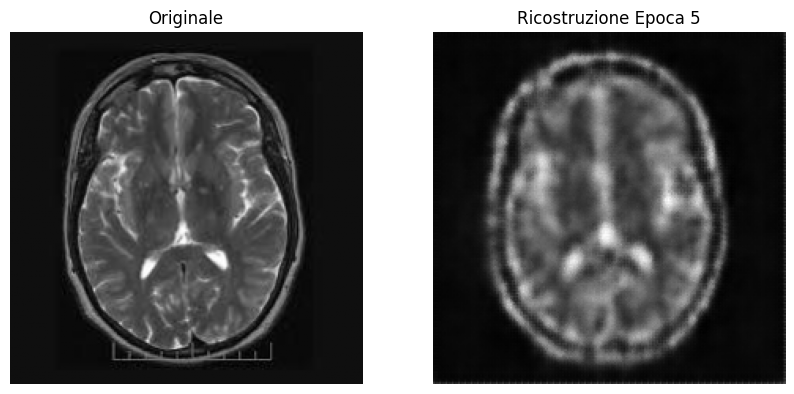

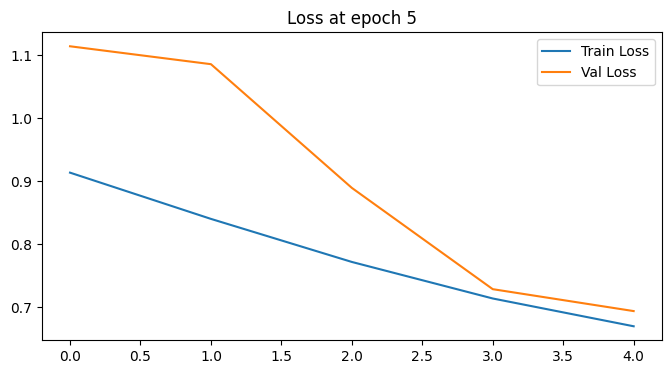

Epoch [6/80] | Beta: 0.00125 | Train Loss: 0.6432 | Val Loss: 0.7092
Epoch [7/80] | Beta: 0.00150 | Train Loss: 0.6233 | Val Loss: 0.8974
Epoch [8/80] | Beta: 0.00175 | Train Loss: 0.5911 | Val Loss: 0.6301
 Best model saved
Epoch [9/80] | Beta: 0.00200 | Train Loss: 0.5707 | Val Loss: 0.6259
 Best model saved
Epoch [10/80] | Beta: 0.00225 | Train Loss: 0.5572 | Val Loss: 0.6156
 Best model saved

--- Reconstruction (Epoca 10) ---


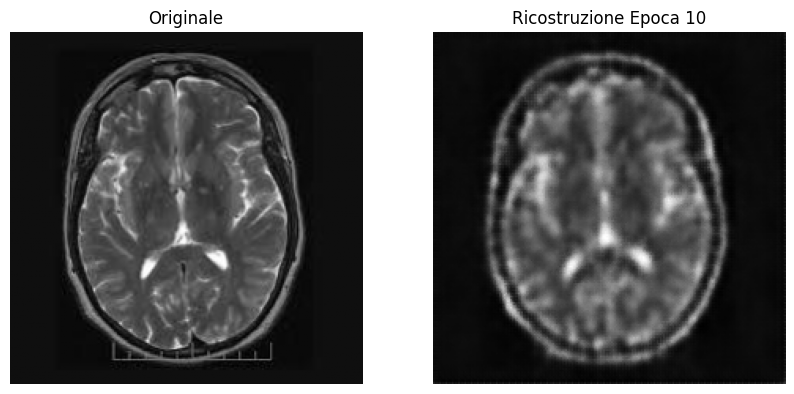

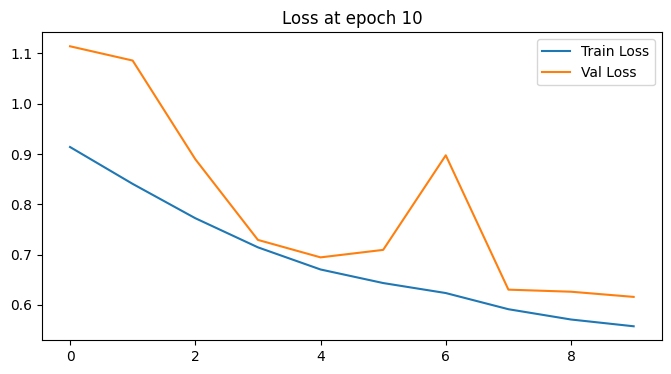

Epoch [11/80] | Beta: 0.00250 | Train Loss: 0.5419 | Val Loss: 0.5971
 Best model saved
Epoch [12/80] | Beta: 0.00275 | Train Loss: 0.5293 | Val Loss: 0.5771
 Best model saved
Epoch [13/80] | Beta: 0.00300 | Train Loss: 0.5192 | Val Loss: 0.5757
 Best model saved
Epoch [14/80] | Beta: 0.00325 | Train Loss: 0.5040 | Val Loss: 0.5583
 Best model saved
Epoch [15/80] | Beta: 0.00350 | Train Loss: 0.4953 | Val Loss: 0.5469
 Best model saved

--- Reconstruction (Epoca 15) ---


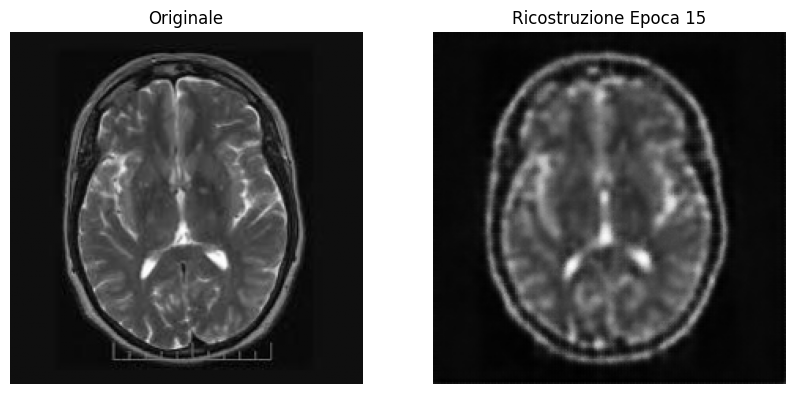

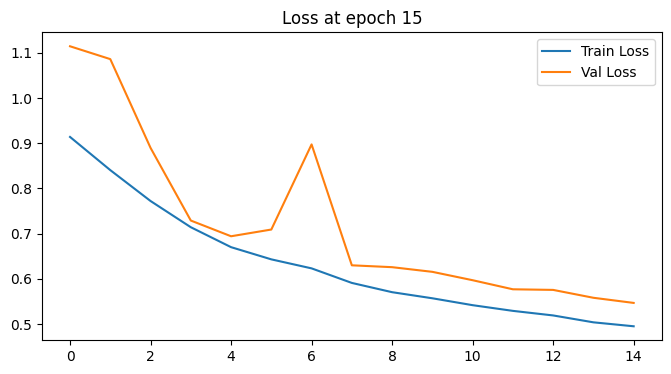

Epoch [16/80] | Beta: 0.00375 | Train Loss: 0.4832 | Val Loss: 0.5494
Epoch [17/80] | Beta: 0.00400 | Train Loss: 0.4748 | Val Loss: 0.5338
 Best model saved
Epoch [18/80] | Beta: 0.00425 | Train Loss: 0.4688 | Val Loss: 0.5516
Epoch [19/80] | Beta: 0.00450 | Train Loss: 0.4615 | Val Loss: 0.5235
 Best model saved
Epoch [20/80] | Beta: 0.00475 | Train Loss: 0.4526 | Val Loss: 0.5187
 Best model saved

--- Reconstruction (Epoca 20) ---


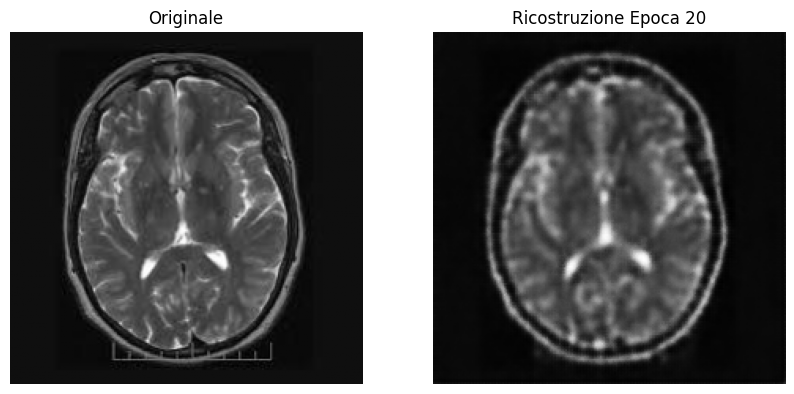

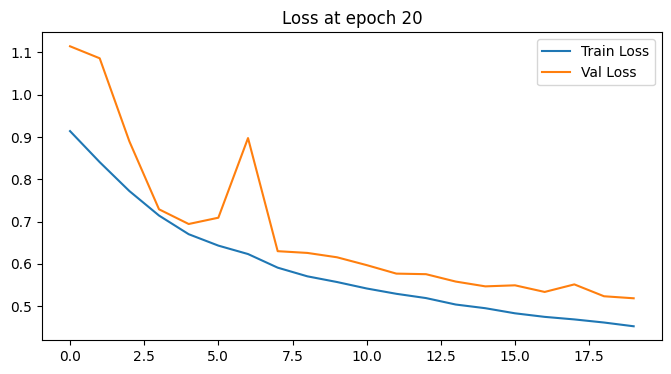

Epoch [21/80] | Beta: 0.00500 | Train Loss: 0.4473 | Val Loss: 0.5080
 Best model saved
Epoch [22/80] | Beta: 0.00500 | Train Loss: 0.4352 | Val Loss: 0.4962
 Best model saved
Epoch [23/80] | Beta: 0.00500 | Train Loss: 0.4270 | Val Loss: 0.4896
 Best model saved
Epoch [24/80] | Beta: 0.00500 | Train Loss: 0.4188 | Val Loss: 0.4825
 Best model saved
Epoch [25/80] | Beta: 0.00500 | Train Loss: 0.4175 | Val Loss: 0.4814
 Best model saved

--- Reconstruction (Epoca 25) ---


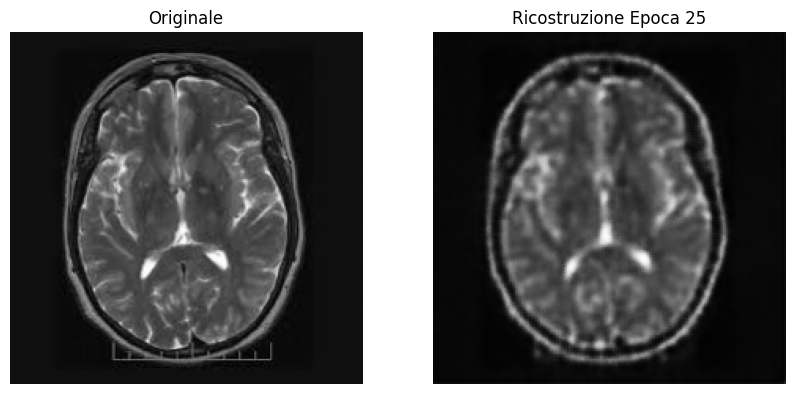

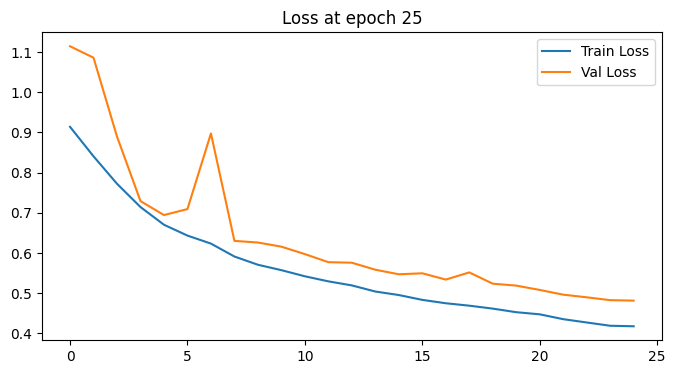

Epoch [26/80] | Beta: 0.00500 | Train Loss: 0.4128 | Val Loss: 0.4836
Epoch [27/80] | Beta: 0.00500 | Train Loss: 0.4116 | Val Loss: 0.5015
Epoch [28/80] | Beta: 0.00500 | Train Loss: 0.4011 | Val Loss: 0.4634
 Best model saved
Epoch [29/80] | Beta: 0.00500 | Train Loss: 0.3920 | Val Loss: 0.4623
 Best model saved
Epoch [30/80] | Beta: 0.00500 | Train Loss: 0.3906 | Val Loss: 0.4564
 Best model saved

--- Reconstruction (Epoca 30) ---


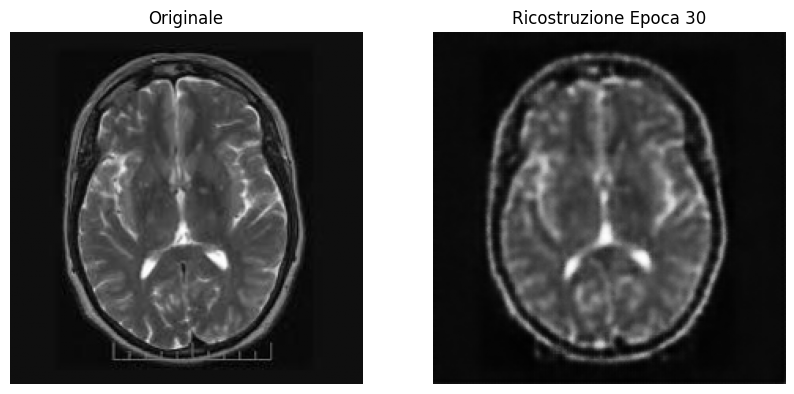

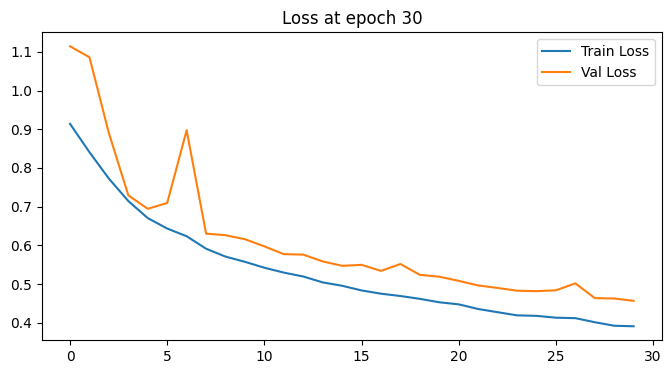

Epoch [31/80] | Beta: 0.00500 | Train Loss: 0.3815 | Val Loss: 0.4515
 Best model saved
Epoch [32/80] | Beta: 0.00500 | Train Loss: 0.3743 | Val Loss: 0.4432
 Best model saved
Epoch [33/80] | Beta: 0.00500 | Train Loss: 0.3749 | Val Loss: 0.4491
Epoch [34/80] | Beta: 0.00500 | Train Loss: 0.3668 | Val Loss: 0.4390
 Best model saved
Epoch [35/80] | Beta: 0.00500 | Train Loss: 0.3622 | Val Loss: 0.4339
 Best model saved

--- Reconstruction (Epoca 35) ---


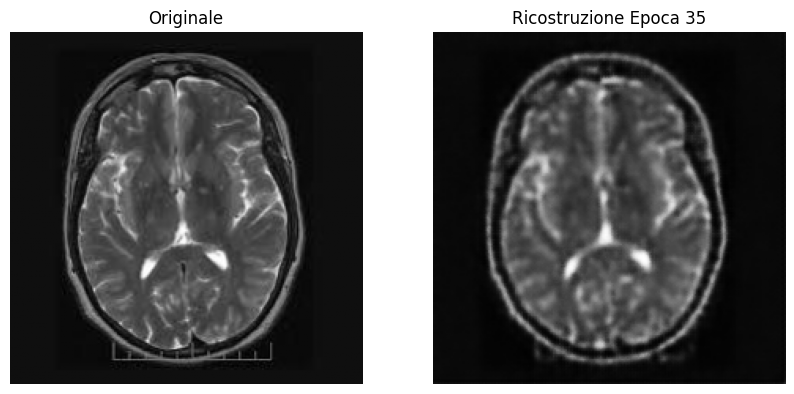

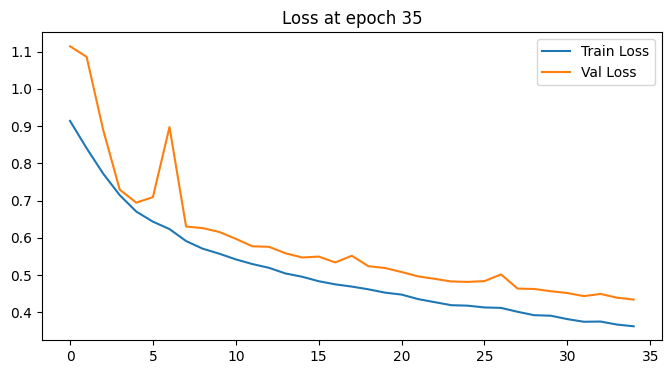

Epoch [36/80] | Beta: 0.00500 | Train Loss: 0.3551 | Val Loss: 0.4391
Epoch [37/80] | Beta: 0.00500 | Train Loss: 0.3577 | Val Loss: 0.4261
 Best model saved
Epoch [38/80] | Beta: 0.00500 | Train Loss: 0.3507 | Val Loss: 0.4318
Epoch [39/80] | Beta: 0.00500 | Train Loss: 0.3502 | Val Loss: 0.4174
 Best model saved
Epoch [40/80] | Beta: 0.00500 | Train Loss: 0.3397 | Val Loss: 0.4185

--- Reconstruction (Epoca 40) ---


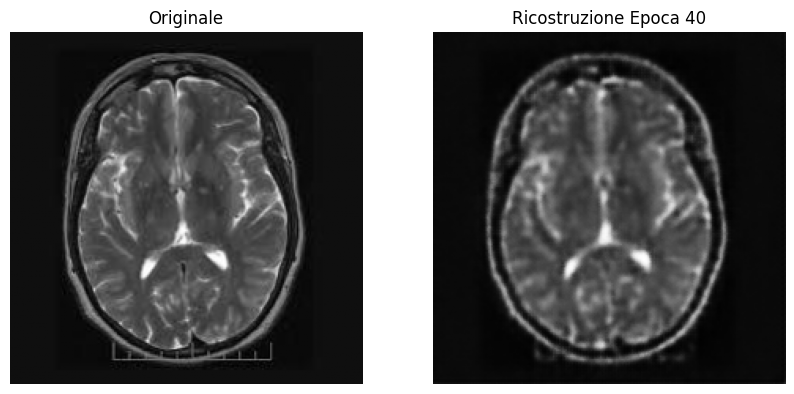

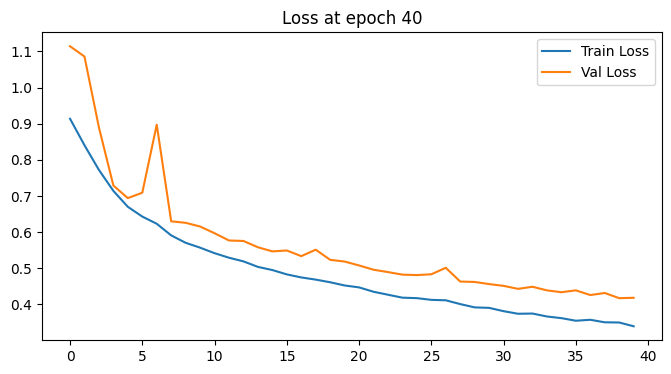

Epoch [41/80] | Beta: 0.00500 | Train Loss: 0.3366 | Val Loss: 0.4148
 Best model saved
Epoch [42/80] | Beta: 0.00500 | Train Loss: 0.3378 | Val Loss: 0.4304
Epoch [43/80] | Beta: 0.00500 | Train Loss: 0.3337 | Val Loss: 0.4157
Epoch [44/80] | Beta: 0.00500 | Train Loss: 0.3271 | Val Loss: 0.4042
 Best model saved
Epoch [45/80] | Beta: 0.00500 | Train Loss: 0.3262 | Val Loss: 0.4044

--- Reconstruction (Epoca 45) ---


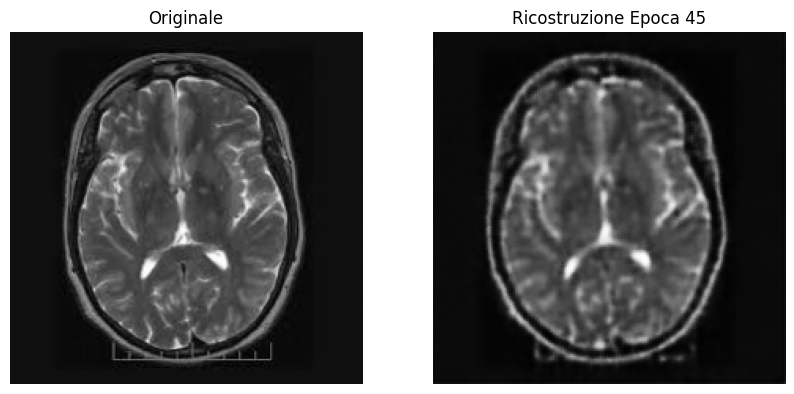

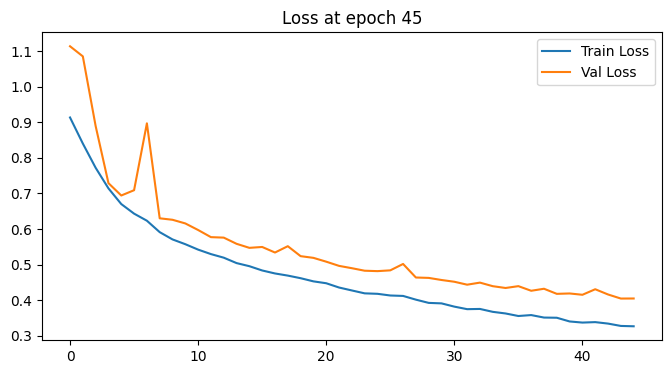

Epoch [46/80] | Beta: 0.00500 | Train Loss: 0.3208 | Val Loss: 0.4000
 Best model saved
Epoch [47/80] | Beta: 0.00500 | Train Loss: 0.3157 | Val Loss: 0.3947
 Best model saved
Epoch [48/80] | Beta: 0.00500 | Train Loss: 0.3129 | Val Loss: 0.3926
 Best model saved
Epoch [49/80] | Beta: 0.00500 | Train Loss: 0.3097 | Val Loss: 0.3899
 Best model saved
Epoch [50/80] | Beta: 0.00500 | Train Loss: 0.3089 | Val Loss: 0.3922

--- Reconstruction (Epoca 50) ---


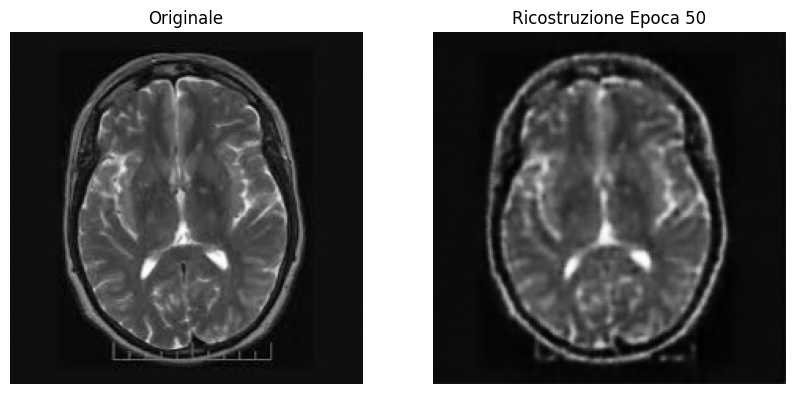

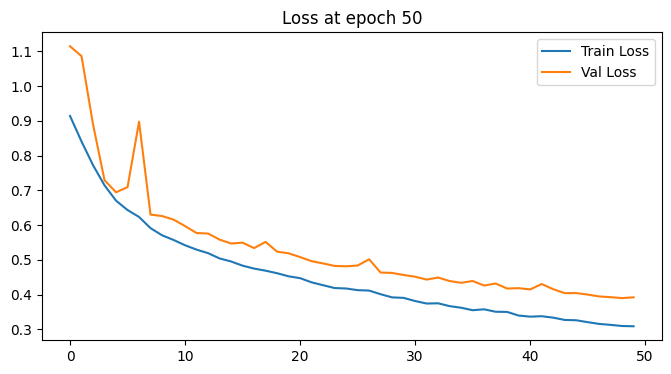

Epoch [51/80] | Beta: 0.00500 | Train Loss: 0.3042 | Val Loss: 0.3991
Epoch [52/80] | Beta: 0.00500 | Train Loss: 0.3023 | Val Loss: 0.3836
 Best model saved
Epoch [53/80] | Beta: 0.00500 | Train Loss: 0.3031 | Val Loss: 0.3824
 Best model saved
Epoch [54/80] | Beta: 0.00500 | Train Loss: 0.3004 | Val Loss: 0.3803
 Best model saved
Epoch [55/80] | Beta: 0.00500 | Train Loss: 0.2983 | Val Loss: 0.3846

--- Reconstruction (Epoca 55) ---


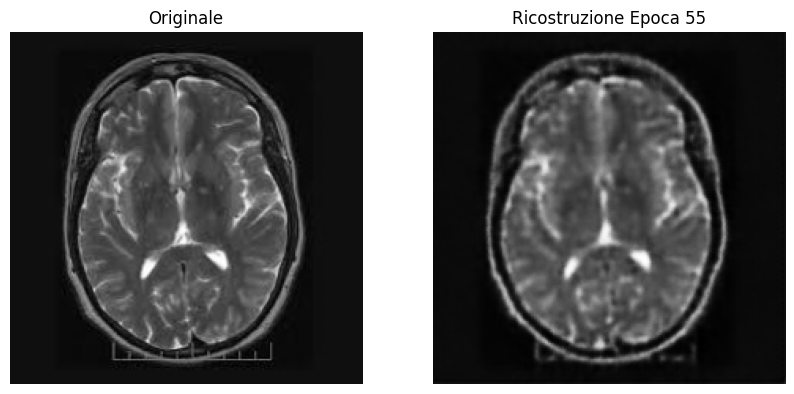

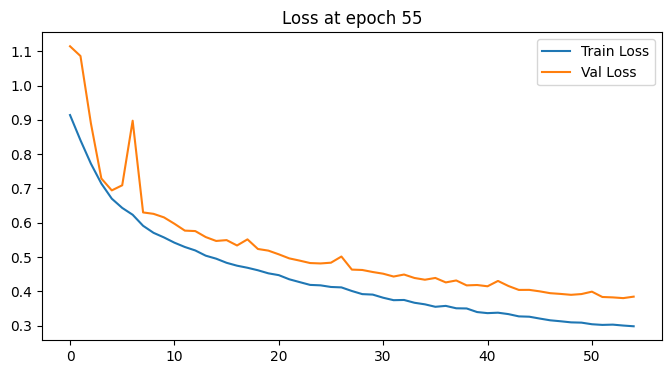

Epoch [56/80] | Beta: 0.00500 | Train Loss: 0.2931 | Val Loss: 0.3797
 Best model saved
Epoch [57/80] | Beta: 0.00500 | Train Loss: 0.2928 | Val Loss: 0.3812
Epoch [58/80] | Beta: 0.00500 | Train Loss: 0.2867 | Val Loss: 0.3731
 Best model saved
Epoch [59/80] | Beta: 0.00500 | Train Loss: 0.2852 | Val Loss: 0.3741
Epoch [60/80] | Beta: 0.00500 | Train Loss: 0.2862 | Val Loss: 0.3746

--- Reconstruction (Epoca 60) ---


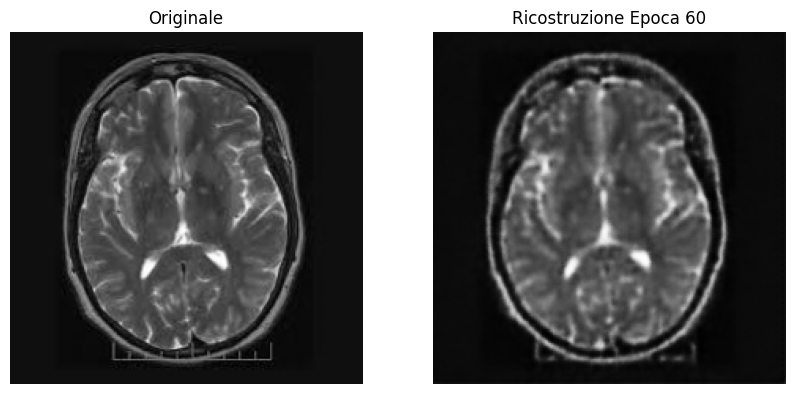

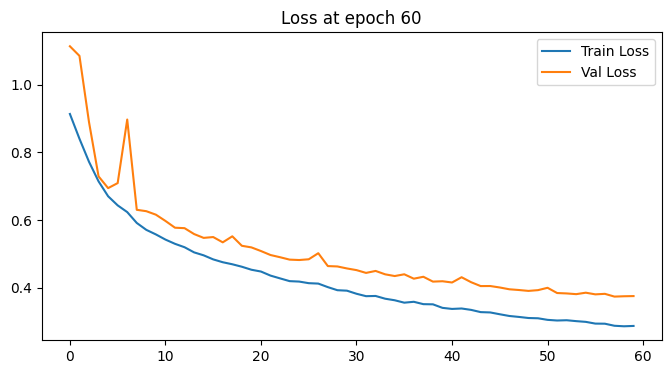

Epoch [61/80] | Beta: 0.00500 | Train Loss: 0.2872 | Val Loss: 0.3730
 Best model saved
Epoch [62/80] | Beta: 0.00500 | Train Loss: 0.2815 | Val Loss: 0.3755
Epoch [63/80] | Beta: 0.00500 | Train Loss: 0.2829 | Val Loss: 0.3729
 Best model saved
Epoch [64/80] | Beta: 0.00500 | Train Loss: 0.2812 | Val Loss: 0.3752
Epoch [65/80] | Beta: 0.00500 | Train Loss: 0.2808 | Val Loss: 0.3681
 Best model saved

--- Reconstruction (Epoca 65) ---


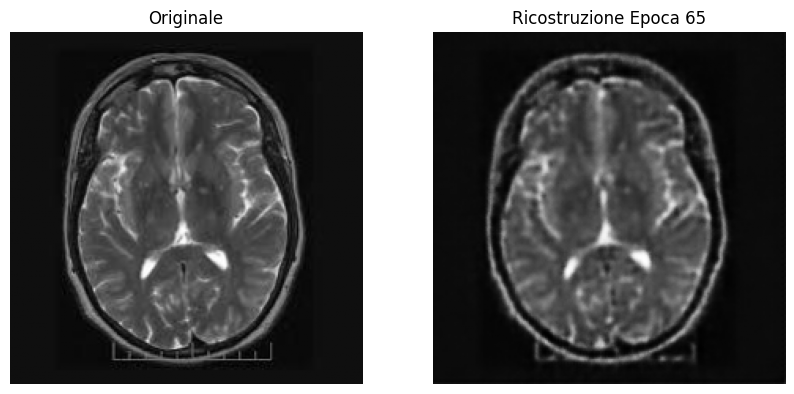

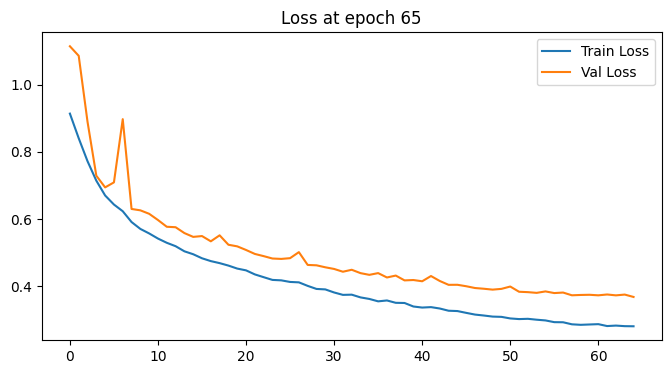

Epoch [66/80] | Beta: 0.00500 | Train Loss: 0.2787 | Val Loss: 0.3670
 Best model saved
Epoch [67/80] | Beta: 0.00500 | Train Loss: 0.2741 | Val Loss: 0.3642
 Best model saved
Epoch [68/80] | Beta: 0.00500 | Train Loss: 0.2782 | Val Loss: 0.3703
Epoch [69/80] | Beta: 0.00500 | Train Loss: 0.2765 | Val Loss: 0.3627
 Best model saved
Epoch [70/80] | Beta: 0.00500 | Train Loss: 0.2735 | Val Loss: 0.3661

--- Reconstruction (Epoca 70) ---


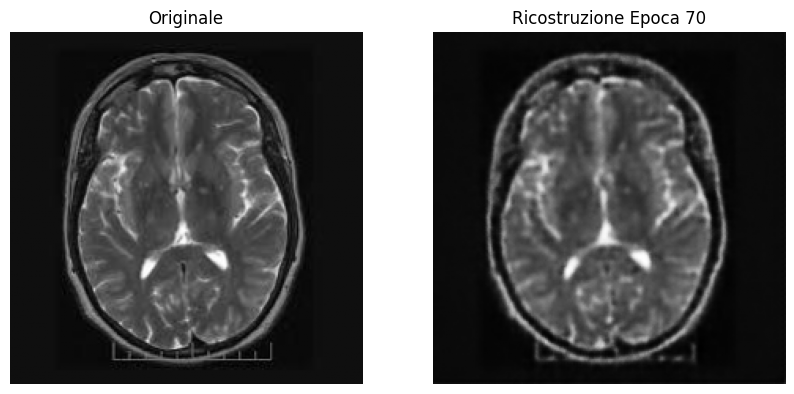

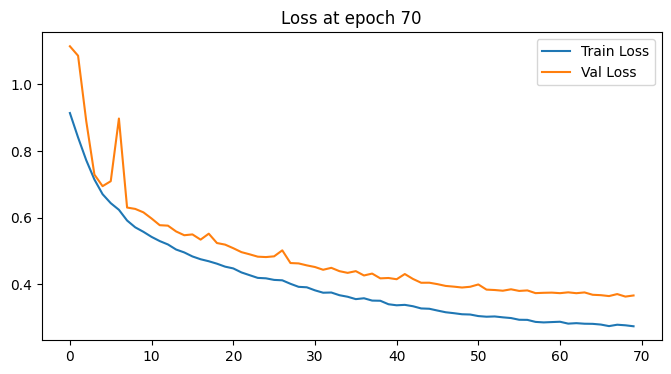

Epoch [71/80] | Beta: 0.00500 | Train Loss: 0.2702 | Val Loss: 0.3639
Epoch [72/80] | Beta: 0.00500 | Train Loss: 0.2715 | Val Loss: 0.3568
 Best model saved
Epoch [73/80] | Beta: 0.00500 | Train Loss: 0.2699 | Val Loss: 0.3586
Epoch [74/80] | Beta: 0.00500 | Train Loss: 0.2701 | Val Loss: 0.3669
Epoch [75/80] | Beta: 0.00500 | Train Loss: 0.2682 | Val Loss: 0.3559
 Best model saved

--- Reconstruction (Epoca 75) ---


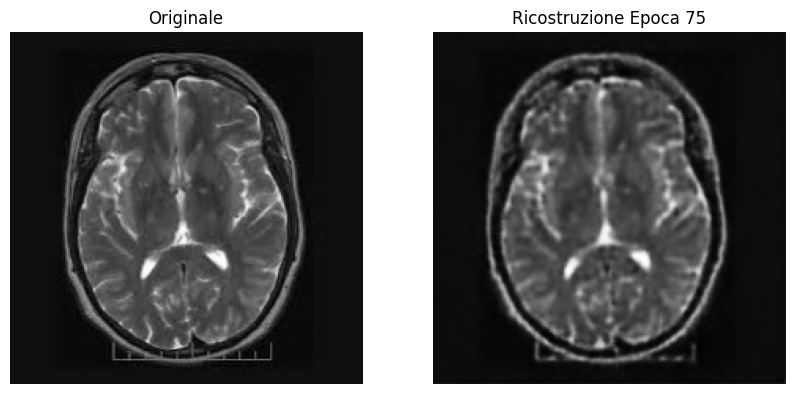

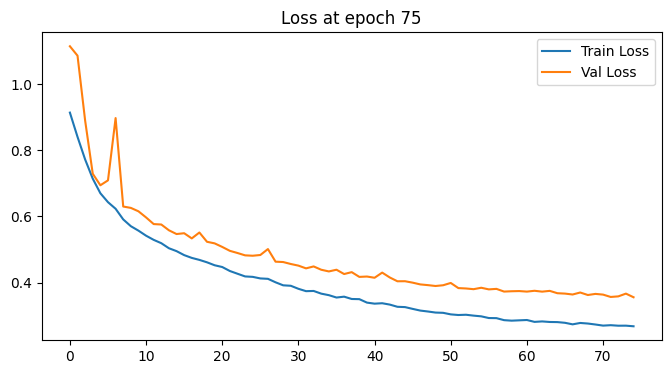

Epoch [76/80] | Beta: 0.00500 | Train Loss: 0.2686 | Val Loss: 0.3556
 Best model saved
Epoch [77/80] | Beta: 0.00500 | Train Loss: 0.2644 | Val Loss: 0.3590
Epoch [78/80] | Beta: 0.00500 | Train Loss: 0.2683 | Val Loss: 0.3542
 Best model saved
Epoch [79/80] | Beta: 0.00500 | Train Loss: 0.2644 | Val Loss: 0.3599
Epoch [80/80] | Beta: 0.00500 | Train Loss: 0.2629 | Val Loss: 0.3559

--- Reconstruction (Epoca 80) ---


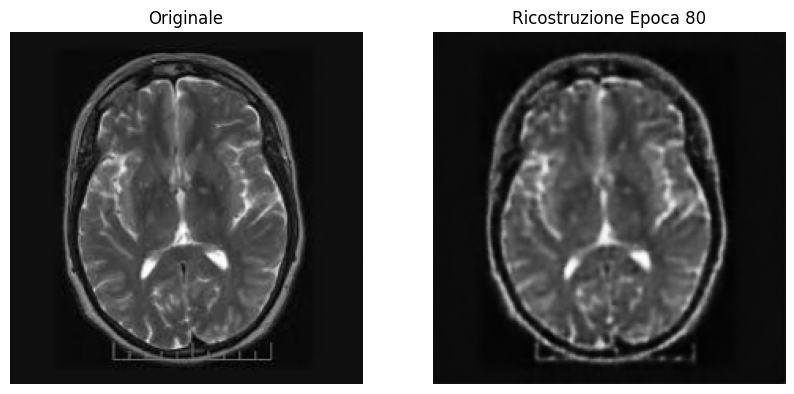

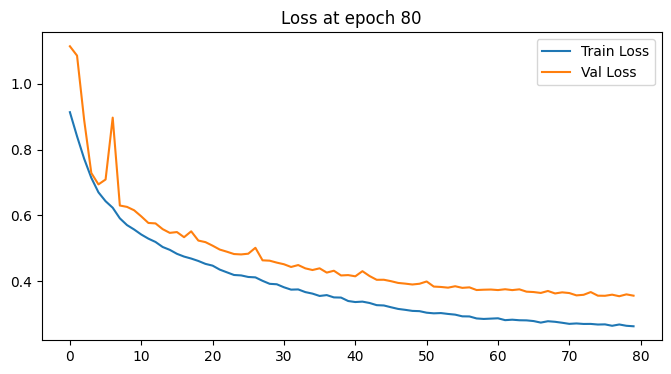

In [15]:
# TRAINING
num_epochs = 80
target_beta = 0.005
warmup_epochs = 20

history_train, history_val = train_vae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs
)

In [18]:
# loading the model
from google.colab import drive
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 1024
model = VAE_V5(latent_dim=latent_dim).to(device)

model_path_v6 = '/content/drive/MyDrive/VAE_Brain_Project/best_model_v5_stabilized.pth'

try:
    checkpoint = torch.load(model_path_v6, map_location=device)
    model.load_state_dict(checkpoint)
    model.eval()
    print(f" Model V6 loaded")
    total_params = sum(p.numel() for p in model.parameters())
    print(f" # of parameters: {total_params:,} parameters.")


except FileNotFoundError:
    print(f" Errore: Il file '{model_path_v6}' non esiste.")

 Model V6 loaded
 # of parameters: 41,246,593 parameters.


In [57]:
def get_anomaly_scores(model, dataloader, device):
    model.eval()
    l1_loss = nn.L1Loss(reduction='none')
    anomaly_scores = []
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            recon, _, _ = model(images)
            error_per_pixel = l1_loss(recon, images)
            mask = (images > 0.05).float()
            masked_error = error_per_pixel * mask
            error_sum = masked_error.view(masked_error.size(0), -1).sum(dim=1)
            pixels_count = mask.view(mask.size(0), -1).sum(dim=1)
            batch_scores = error_sum / (pixels_count + 1e-8)
            anomaly_scores.extend(batch_scores.cpu().numpy())
    return anomaly_scores

In [54]:
def get_anomaly_scores(model, dataloader, device):
    model.eval()
    mse_loss = nn.MSELoss(reduction='none') # reduction none = doesnt aggragate and returns avg error per pixel

    anomaly_scores = []
    with torch.no_grad():
        for images in dataloader:
            images = images.to(device)
            recon, _, _ = model(images) # mu and logvar not needed
            error_per_pixel = mse_loss(recon, images)
            mask = (images > 0.05).float()
            masked_error = error_per_pixel * mask
            error_sum = masked_error.view(masked_error.size(0), -1).sum(dim=1)
            pixels_count = mask.view(mask.size(0), -1).sum(dim=1)
            batch_scores = error_sum / (pixels_count + 1e-8)
            anomaly_scores.extend(batch_scores.cpu().numpy())

    return anomaly_scores

In [58]:
file_anomalie_totali = glob.glob("/content/dataset_local/**/Testing/*/*.jpg", recursive=True)
file_anomalie_totali = [f for f in file_anomalie_totali if "notumor" not in f]

# - val_anomalie_files: for threhold calibration
# - test_anomalie_files: for final test
val_anomalie_files, test_anomalie_files = train_test_split(
    file_anomalie_totali, test_size=0.80, random_state=42
)

print(f"Tumors for Validation: {len(val_anomalie_files)}")
print(f"Tumors for final test: {len(test_anomalie_files)}")

#  Loader for calibration (healthy from Val + Tumors from Val)
val_sani_loader = DataLoader(
    BrainDataset([val_subset.dataset.file_list[i] for i in val_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False
)
val_anomalie_loader = DataLoader(
    BrainDataset(val_anomalie_files, transform=base_transform),
    batch_size=batch_size, shuffle=False
)

#  Loader for final test (healthy from Test + tumor from Test)
test_loader_sani = DataLoader(
    BrainDataset([test_healthy_subset.dataset.file_list[i] for i in test_healthy_subset.indices], transform=base_transform),
    batch_size=batch_size, shuffle=False
)
test_loader_anomalie = DataLoader(
    BrainDataset(test_anomalie_files, transform=base_transform),
    batch_size=batch_size, shuffle=False
)

val_sani_scores = get_anomaly_scores(model, val_sani_loader, device)
val_anno_scores = get_anomaly_scores(model, val_anomalie_loader, device)

# Label Validation (0=Sano, 1=Tumore) ---> [0, 0, ..., 1, 1, ...]
y_val_true = [0] * len(val_sani_scores) + [1] * len(val_anno_scores)
y_val_scores = val_sani_scores + val_anno_scores


fpr_val, tpr_val, thresholds_val = roc_curve(y_val_true, y_val_scores)
optimal_idx = np.argmax(tpr_val - fpr_val)
optimal_threshold = thresholds_val[optimal_idx]

print(f" Optimal threshold calibrated on mixed validation: {optimal_threshold:.6f}")

Tumors for Validation: 181
Tumors for final test: 725
 Optimal threshold calibrated on mixed validation: 0.065928


Test set size: 885


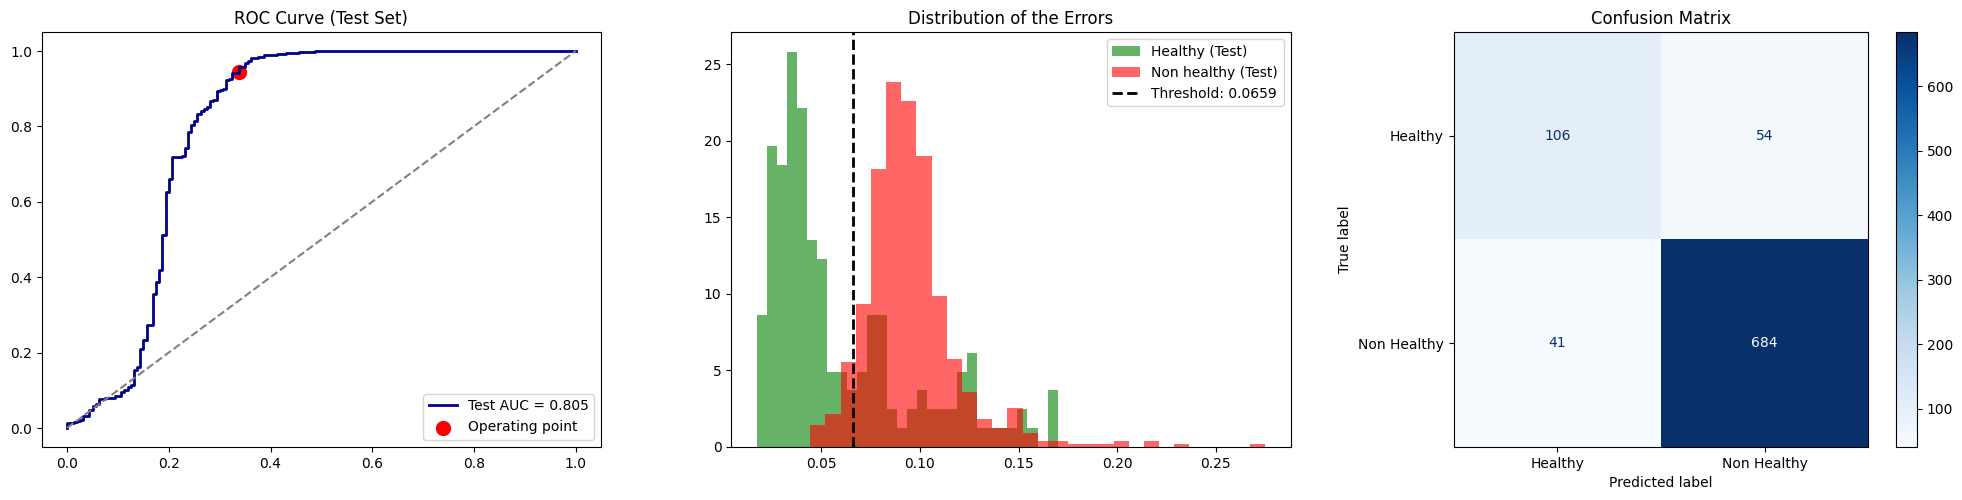


   Final Report 
Applied threshold:     0.065928
----------------------------------------
Accuracy:              0.8927
AUC Score:             0.8051
Recall (Sensitivity):  0.9434
Specificity:           0.6625
F1-Score:              0.9351
No Information Rate:   0.8192
----------------------------------------
              precision    recall  f1-score   support

     Healthy       0.72      0.66      0.69       160
 Non healthy       0.93      0.94      0.94       725

    accuracy                           0.89       885
   macro avg       0.82      0.80      0.81       885
weighted avg       0.89      0.89      0.89       885



In [59]:
# Calcolo Score Test
test_healthy_scores = get_anomaly_scores(model, test_loader_sani, device)
test_anomaly_scores = get_anomaly_scores(model, test_loader_anomalie, device)

# label for test (0 = Sano, 1 = Tumore) ---> [0, 0, ..., 1, 1, ...]
y_test_true = np.array([0] * len(test_healthy_scores) + [1] * len(test_anomaly_scores))
y_test_scores = np.concatenate([test_healthy_scores, test_anomaly_scores])

print(f"Test set size: {len(y_test_true)}")

y_pred = [1 if s > optimal_threshold else 0 for s in y_test_scores]

auc_value = roc_auc_score(y_test_true, y_test_scores)
acc_modello = accuracy_score(y_test_true, y_pred)
f1 = f1_score(y_test_true, y_pred)
recall = recall_score(y_test_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test_true, y_pred).ravel()
specificity = tn / (tn + fp)

# nir
conteggio_classi = np.bincount(y_test_true)
nir = np.max(conteggio_classi) / len(y_test_true)

# Plotting
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test_true, y_test_scores)
ax1.plot(fpr, tpr, color='darkblue', lw=2, label=f'Test AUC = {auc_value:.3f}')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.scatter(1-specificity, recall, color='red', s=100, label='Operating point')
ax1.set_title('ROC Curve (Test Set)')
ax1.legend(loc="lower right")

# Histogram
ax2.hist(test_healthy_scores, bins=30, alpha=0.6, label='Healthy (Test)', color='green', density=True)
ax2.hist(test_anomaly_scores, bins=30, alpha=0.6, label='Non healthy (Test)', color='red', density=True)
ax2.axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold: {optimal_threshold:.4f}')
ax2.set_title('Distribution of the Errors')
ax2.legend()

# Confusion matrix
cm = confusion_matrix(y_test_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Non Healthy'])
disp.plot(ax=ax3, cmap='Blues', values_format='d')
ax3.set_title(f'Confusion Matrix')

plt.tight_layout()
plt.show()

# Report
print(f"\n" + "="*40)
print(f"   Final Report ")
print(f"="*40)
print(f"Applied threshold:     {optimal_threshold:.6f}")
print("-" * 40)
print(f"Accuracy:              {acc_modello:.4f}")
print(f"AUC Score:             {auc_value:.4f}")
print(f"Recall (Sensitivity):  {recall:.4f}")
print(f"Specificity:           {specificity:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"No Information Rate:   {nir:.4f}")
print("-" * 40)
print(classification_report(y_test_true, y_pred, target_names=['Healthy', 'Non healthy']))

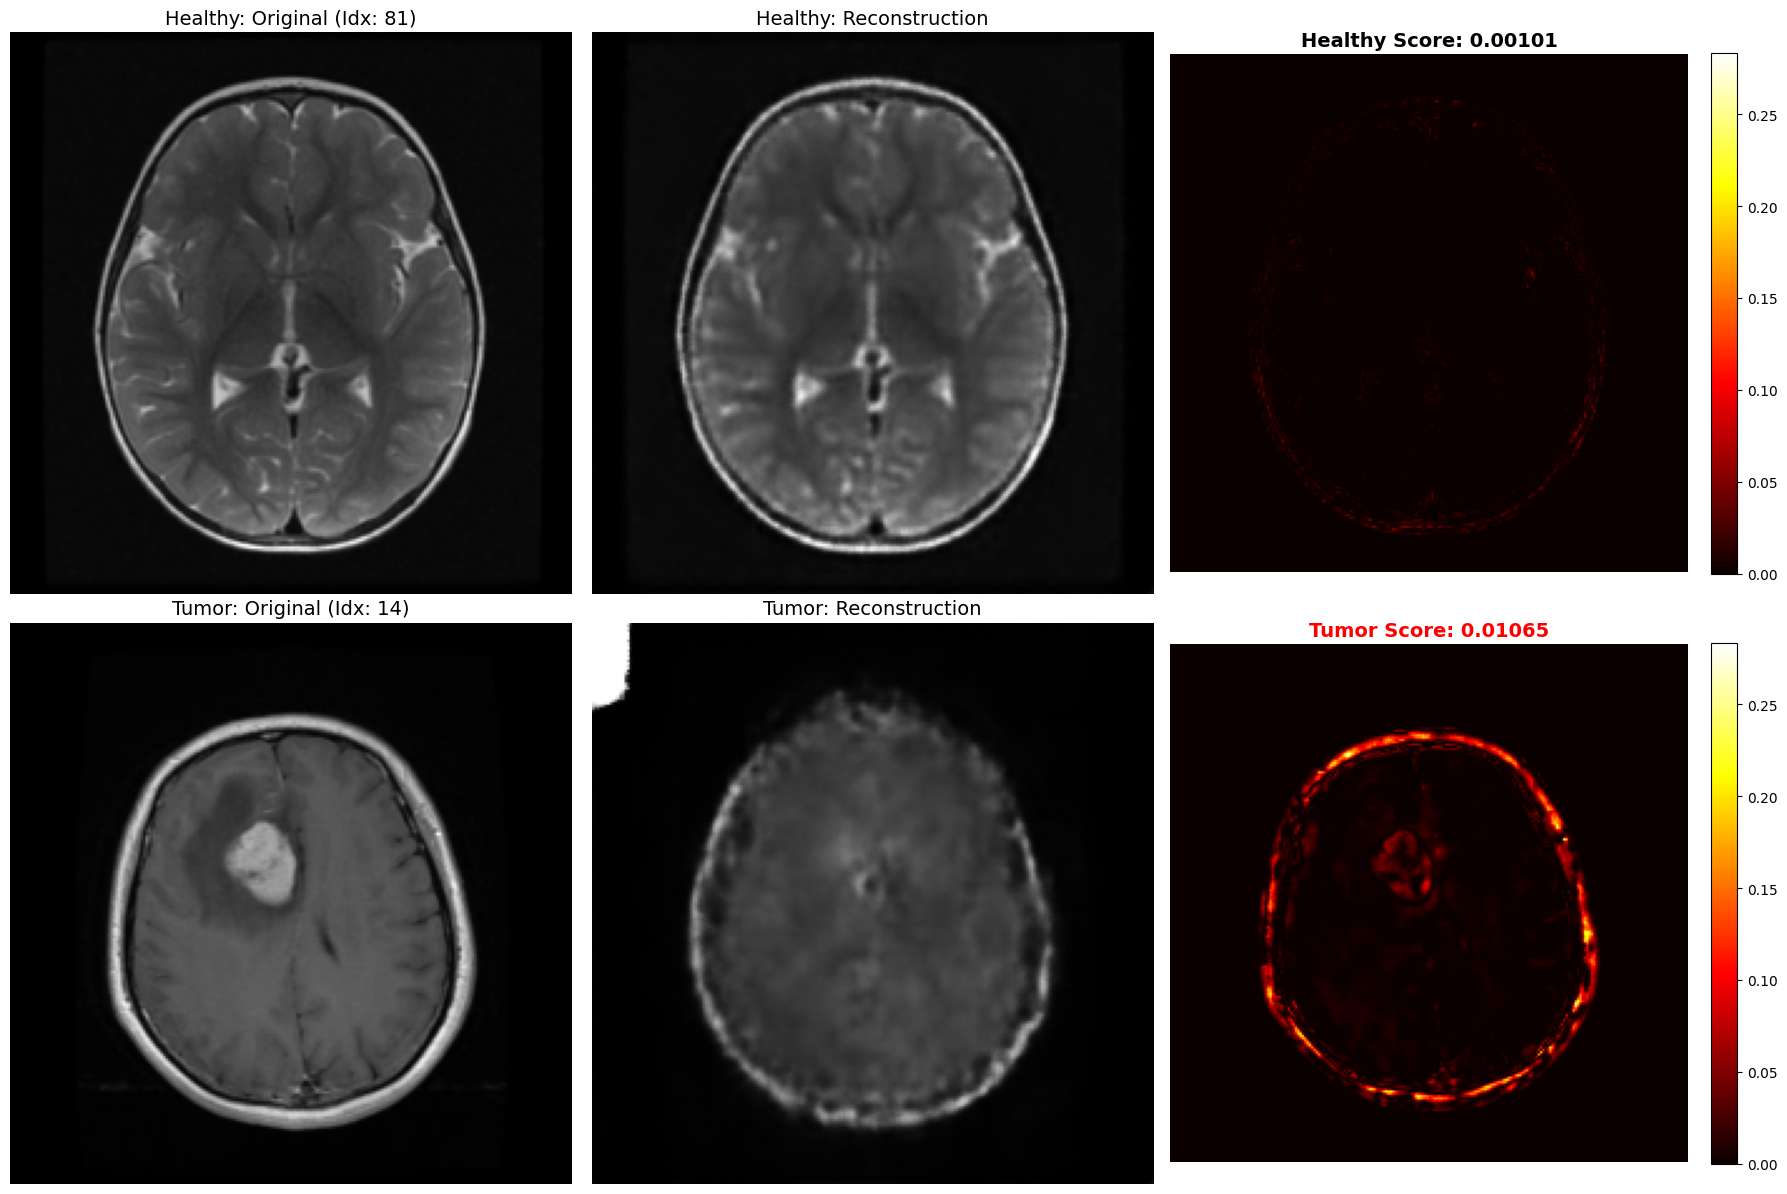

In [53]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

def plot_reconstruction_comparison(model, healthy_dataset, tumor_dataset, device, index=None):
    model.eval()

    mse_loss = nn.MSELoss(reduction='none')

    if index is None:
        idx_h = random.randint(0, len(healthy_dataset) - 1)
        idx_t = random.randint(0, len(tumor_dataset) - 1)
    else:
        idx_h = min(index, len(healthy_dataset) - 1)
        idx_t = min(index, len(tumor_dataset) - 1)

    sample_h = healthy_dataset[idx_h]
    sample_t = tumor_dataset[idx_t]

    x_h = sample_h[0] if isinstance(sample_h, (list, tuple)) else sample_h
    x_t = sample_t[0] if isinstance(sample_t, (list, tuple)) else sample_t

    x_h = x_h.unsqueeze(0).to(device)
    x_t = x_t.unsqueeze(0).to(device)

    with torch.no_grad():
        recon_h, _, _ = model(x_h)
        recon_t, _, _ = model(x_t)

        def get_map_and_score(original, reconstructed):
            mask = (original > 0.05).float()

            error_map = mse_loss(reconstructed, original) * mask
            score = error_map.sum() / (mask.sum() + 1e-8)
            return error_map.cpu().squeeze().numpy(), score.item()

        map_h, score_h = get_map_and_score(x_h, recon_h)
        map_t, score_t = get_map_and_score(x_t, recon_t)

    img_h = x_h.cpu().squeeze().numpy()
    rec_h = recon_h.cpu().squeeze().numpy()
    img_t = x_t.cpu().squeeze().numpy()
    rec_t = recon_t.cpu().squeeze().numpy()


    vmax_shared = max(map_h.max(), map_t.max())

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    def plot_row(row_idx, img, rec, err_map, score, title_prefix, score_color, img_index):
        axes[row_idx, 0].imshow(img, cmap='gray')
        axes[row_idx, 0].set_title(f"{title_prefix}: Original (Idx: {img_index})", fontsize=14)
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(rec, cmap='gray')
        axes[row_idx, 1].set_title(f"{title_prefix}: Reconstruction", fontsize=14)
        axes[row_idx, 1].axis('off')


        im = axes[row_idx, 2].imshow(err_map, cmap='hot', vmin=0, vmax=vmax_shared)
        axes[row_idx, 2].set_title(f"{title_prefix} Score: {score:.5f}", color=score_color, fontweight='bold', fontsize=14)
        axes[row_idx, 2].axis('off')

        fig.colorbar(im, ax=axes[row_idx, 2], fraction=0.046, pad=0.04)

    plot_row(0, img_h, rec_h, map_h, score_h, "Healthy", "black", idx_h)
    plot_row(1, img_t, rec_t, map_t, score_t, "Tumor", "red", idx_t)

    plt.tight_layout()
    plt.show()

plot_reconstruction_comparison(model, test_loader_sani.dataset, test_loader_anomalie.dataset, device)

--- TEST 1: Interpolation HEALTHY -> HEALTHY ---


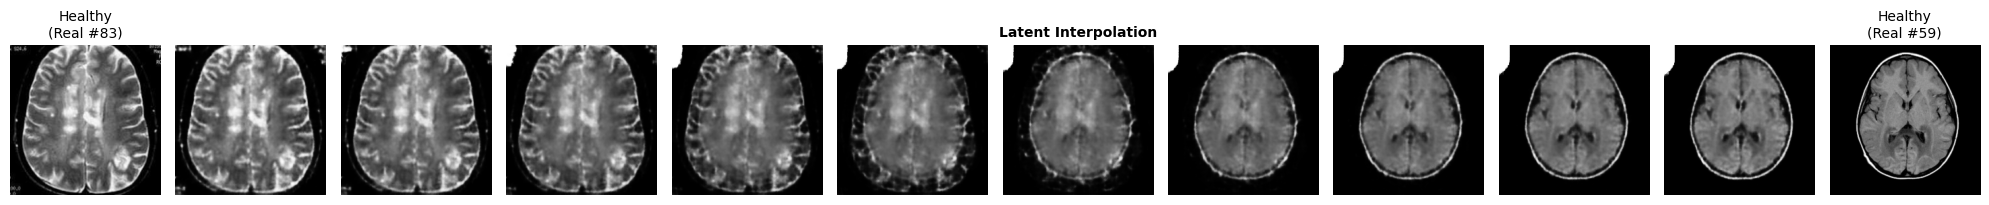


--- TEST 2: Interpolation HEALTHY -> TUMOR ---


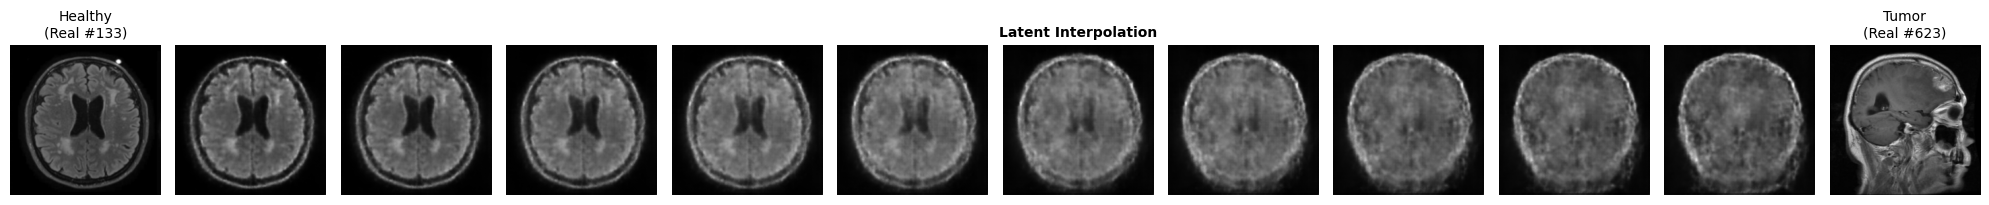

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

def get_random_sample(loader, device):
    dataset = loader.dataset
    idx = random.randint(0, len(dataset) - 1)
    sample = dataset[idx]

    if isinstance(sample, (tuple, list)):
        img = sample[0]
    else:
        img = sample

    if not isinstance(img, torch.Tensor):
        img = torch.tensor(img)

    return img.unsqueeze(0).to(device), idx

def visualize_random_interpolation(model, loader_start, loader_end, device, label_start="Healthy", label_end="Healthy", steps=10):
    model.eval()

    img_start, idx_start = get_random_sample(loader_start, device)
    img_end, idx_end = get_random_sample(loader_end, device)

    with torch.no_grad():
        h_start = model.encoder(img_start)
        h_start = torch.flatten(h_start, start_dim=1)
        mu_start = model.fc_mu(h_start)

        h_end = model.encoder(img_end)
        h_end = torch.flatten(h_end, start_dim=1)
        mu_end = model.fc_mu(h_end)

    interpolated_images = []
    alphas = np.linspace(0, 1, steps)

    with torch.no_grad():
        for alpha in alphas:
            z_interp = (1 - alpha) * mu_start + alpha * mu_end
            dec_hid = model.decoder_input(z_interp)
            recon = model.decoder(model.unflatten(dec_hid))
            interpolated_images.append(recon.cpu().squeeze().numpy())


    plt.figure(figsize=(20, 4))


    plt.subplot(1, steps + 2, 1)
    plt.imshow(img_start.cpu().squeeze(), cmap='gray')
    plt.title(f"{label_start}\n(Real #{idx_start})", fontsize=10)
    plt.axis('off')


    for i, img in enumerate(interpolated_images):
        plt.subplot(1, steps + 2, i + 2)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if i == steps // 2:
            plt.title("Latent Interpolation", fontsize=10, fontweight='bold')


    plt.subplot(1, steps + 2, steps + 2)
    plt.imshow(img_end.cpu().squeeze(), cmap='gray')
    plt.title(f"{label_end}\n(Real #{idx_end})", fontsize=10)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


print("--- TEST 1: Interpolation HEALTHY -> HEALTHY ---")
visualize_random_interpolation(model, test_loader_sani, test_loader_sani, device, label_start="Healthy", label_end="Healthy")

print("\n--- TEST 2: Interpolation HEALTHY -> TUMOR ---")
visualize_random_interpolation(model, test_loader_sani, test_loader_anomalie, device, label_start="Healthy", label_end="Tumor")